### Reusable Plotting Code for Trials

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd
import os

dir_path = os.environ.get("CCIR_DIR", r"C:\Users\Faruk\Code\CCIR_Project")
results_path = rf"{dir_path}/MAHGCNExperiments/results_table.csv"

In [ ]:
def plot_loss_curves(trial_id, experiment="MAHGCNExperiments", ylim=None, share_y=False):
    trial_dir = rf"{dir_path}/{experiment}/{trial_id}"
    data = np.load(rf"{trial_dir}/train_val_loss.npy")
    train_losses = data[:, 0]
    val_losses   = data[:, 1]
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses,   label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Loss Curves — {trial_id}")
    plt.legend()
    if share_y and ylim is not None:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.savefig(rf"{trial_dir}/plots/loss_curves.png", dpi=150)
    plt.show()


def plot_predictions(trial_id, experiment="MAHGCNExperiments", train=False):
    trial_dir = rf"{dir_path}/{experiment}/{trial_id}"
    config    = json.load(open(rf"{trial_dir}/config.json"))

    if train:
        preds = np.load(rf"{trial_dir}/best_train_preds.npy")
        true  = np.load(rf"{trial_dir}/best_train_true.npy")
        split_label = "Train"
        save_name   = "predictions_train.png"
    else:
        preds = np.load(rf"{trial_dir}/best_val_preds.npy")
        true  = np.load(rf"{trial_dir}/best_val_true.npy")
        split_label = "Val"
        save_name   = "predictions.png"

    if config["age_norm"] == "minmax_0_1":
        max_age = 100 if "NKItrimmed" not in config["train_datasets"].split("_") else 22
        preds = preds * max_age
        true  = true  * max_age
        label = "Age (years)"
    else:
        label = "Age (z-scored)"

    r = np.corrcoef(true, preds)[0, 1]
    mae = np.mean(np.abs(preds - true))

    plt.figure(figsize=(5, 5))
    plt.scatter(true, preds, alpha=0.5, s=20)
    lims = [min(true.min(), preds.min()) - 1, max(true.max(), preds.max()) + 1]
    plt.plot(lims, lims, "r--", linewidth=1)
    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"Predictions vs Ground Truth ({split_label}) — {trial_id}\nr={r:.3f}, MAE={mae:.2f}")
    plt.tight_layout()
    plt.savefig(rf"{trial_dir}/plots/{save_name}", dpi=150)
    plt.show()

In [ ]:
_EMBEDDED_PARAMS = {
    "gat_hidden_dim":  lambda cfg: int(cfg["gcn_mode"].split("_")[1]),
    "gat_num_heads":   lambda cfg: int(cfg["gcn_mode"].split("_")[2]),
    "gat_num_layers":  lambda cfg: int(cfg["gcn_mode"].split("_")[3]),
    "wide_hidden_dim": lambda cfg: int(cfg["gcn_mode"].split("_")[-1]),
}

def _extract_hyperparam(cfg, hyperparam):
    if hyperparam in _EMBEDDED_PARAMS:
        try:
            return _EMBEDDED_PARAMS[hyperparam](cfg)
        except (IndexError, ValueError, KeyError):
            return None
    return cfg.get(hyperparam)


def plot_hyperparam_axis(trial_ids, hyperparam, metric, experiment="MAHGCNExperiments", title=None):
    exp_results_path = rf"{dir_path}/{experiment}/results_table.csv"
    results_df = pd.read_csv(exp_results_path)

    if metric in ("best_val_r", "best_val_mae"):
        rs, maes = {}, {}
        for tid in trial_ids:
            trial_dir  = rf"{dir_path}/{experiment}/{tid}"
            preds_file = rf"{trial_dir}/best_val_preds.npy"
            true_file  = rf"{trial_dir}/best_val_true.npy"
            cfg        = json.load(open(rf"{trial_dir}/config.json", encoding="utf-8-sig"))
            if os.path.exists(preds_file) and os.path.exists(true_file):
                preds = np.load(preds_file)
                true  = np.load(true_file)
                if cfg["age_norm"] == "minmax_0_1":
                    max_age = 100 if "NKItrimmed" not in cfg["train_datasets"].split("_") else 22
                    preds, true = preds * max_age, true * max_age
                rs[tid]   = np.corrcoef(true, preds)[0, 1]
                maes[tid] = float(np.mean(np.abs(preds - true)))

    x_vals, y_vals, labels = [], [], []
    for tid in trial_ids:
        trial_dir = rf"{dir_path}/{experiment}/{tid}"
        cfg_path  = rf"{trial_dir}/config.json"
        if not os.path.exists(cfg_path):
            print(f"Skipping {tid} — config missing")
            continue
        cfg = json.load(open(cfg_path, encoding="utf-8-sig"))

        x = _extract_hyperparam(cfg, hyperparam)
        if x is None:
            print(f"Skipping {tid} — '{hyperparam}' not extractable from config")
            continue

        if metric == "best_val_r":
            y = rs.get(tid)
        elif metric == "best_val_mae":
            y = maes.get(tid)
        else:
            row = results_df[results_df["trial_id"] == tid]
            y = row[metric].values[0] if len(row) else None

        if y is None:
            print(f"Skipping {tid} — metric missing")
            continue

        x_vals.append(x)
        y_vals.append(y)
        labels.append(tid)

    if not x_vals:
        print("No data to plot.")
        return

    numeric_x = all(isinstance(v, (int, float)) for v in x_vals)
    use_log = numeric_x and (
        hyperparam in ("lr", "weight_decay")
        or (max(x_vals) / (min(x_vals) + 1e-12) > 10)
    )

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.scatter(x_vals, y_vals, zorder=3)
    for x, y, lbl in zip(x_vals, y_vals, labels):
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(4, 4), fontsize=7)

    if use_log:
        ax.set_xscale("log")

    ax.set_xlabel(hyperparam)
    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} vs {hyperparam}")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

### All Trials — Plots

In [ ]:
def get_top_performers(df, trial_prefix, experiment="MAHGCNExperiments", metric="best_state_val_loss", top_n=-1):
    trials = df[df["trial_id"].str.startswith(trial_prefix)].copy()
    rs, maes = [], []
    for tid in trials["trial_id"]:
        trial_dir  = rf"{dir_path}/{experiment}/{tid}"
        preds_file = rf"{trial_dir}/best_val_preds.npy"
        true_file  = rf"{trial_dir}/best_val_true.npy"
        cfg        = json.load(open(rf"{trial_dir}/config.json", encoding="utf-8-sig"))

        if os.path.exists(preds_file) and os.path.exists(true_file):
            preds = np.load(preds_file)
            true  = np.load(true_file)
            if cfg["age_norm"] == "minmax_0_1":
                max_age = 100 if "NKItrimmed" not in cfg.get("train_datasets", "_").split("_") else 22
                preds, true = preds * max_age, true * max_age
            rs.append(round(np.corrcoef(true, preds)[0, 1], 3))
            maes.append(round(float(np.mean(np.abs(preds - true))), 3))
        else:
            rs.append(None)
            maes.append(None)

    trials["best_val_r"]   = rs
    trials["best_val_mae"] = maes

    ascending = metric not in ("best_val_r",)
    return trials.sort_values(by=metric, ascending=ascending)[: None if top_n == -1 else top_n]

In [ ]:
experiment = "MAHGCNExperiments"
df = pd.read_csv(rf"{dir_path}/{experiment}/results_table.csv")

top = get_top_performers(df, "trial_23d", experiment=experiment, metric="best_val_r", top_n=10)

trial_ids_to_plot = [
    trial_id for trial_id in top["trial_id"].values
    if os.path.exists(rf"{dir_path}/{experiment}/{trial_id}/train_val_loss.npy")
    and os.path.exists(rf"{dir_path}/{experiment}/{trial_id}/best_val_preds.npy")
]

global_min, global_max = float("inf"), float("-inf")
for trial_id in trial_ids_to_plot:
    data = np.load(rf"{dir_path}/{experiment}/{trial_id}/train_val_loss.npy")
    global_min = min(global_min, data.min())
    global_max = max(global_max, data.max())
shared_ylim = (max(0, global_min * 0.95), global_max * 1.05)

for trial_id in trial_ids_to_plot:
    print(f"\n{'='*50}\n{trial_id}\n{'='*50}")
    plot_loss_curves(trial_id, experiment=experiment, ylim=shared_ylim, share_y=False)
    plot_predictions(trial_id, experiment=experiment, train=False)
    plot_predictions(trial_id, experiment=experiment, train=True)

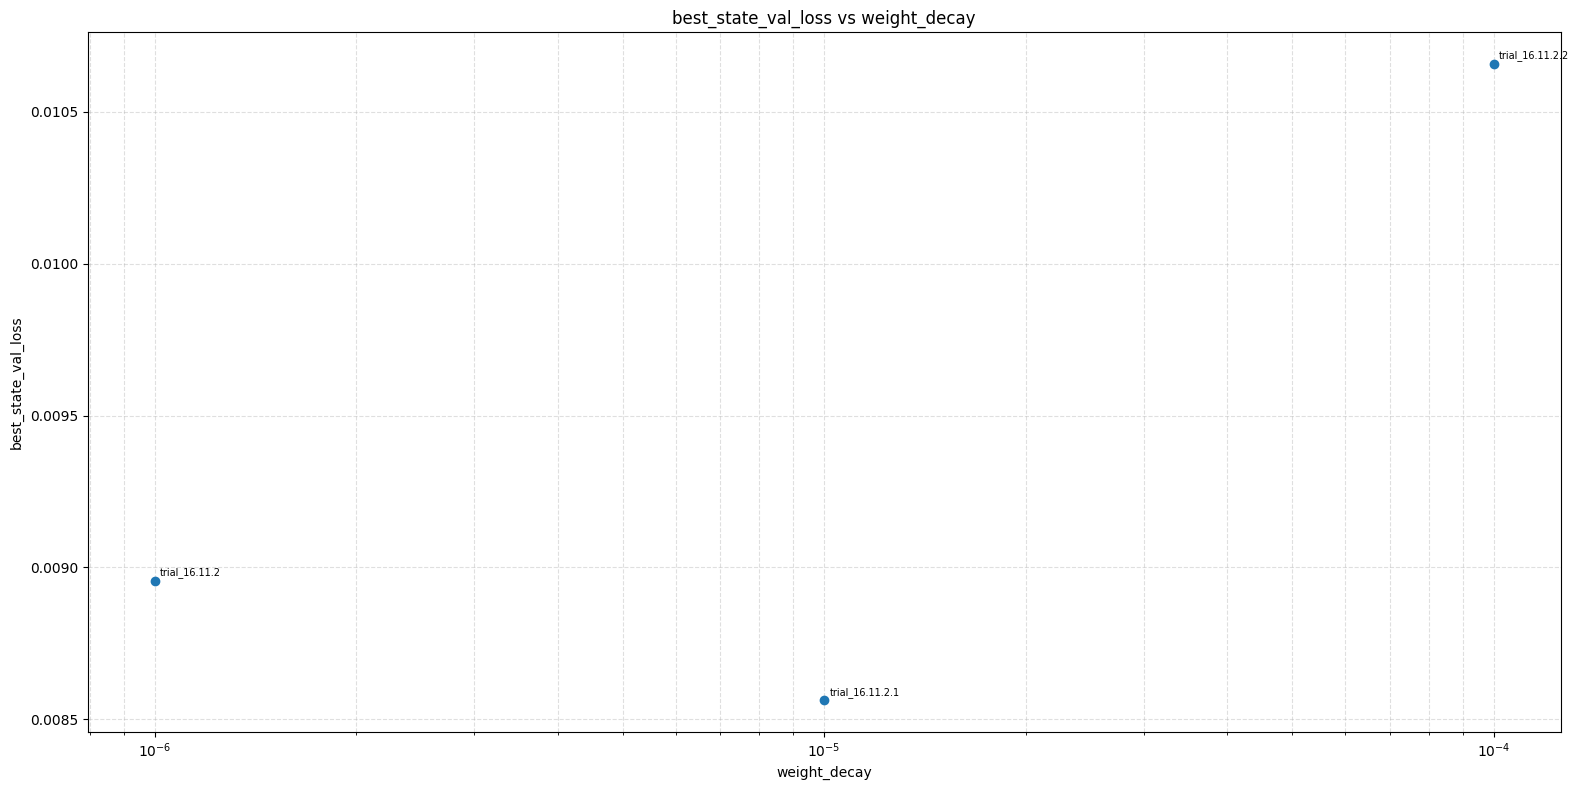

In [5]:
# Plots loss curves + predictions for every completed trial in results_table.csv
df = pd.read_csv(results_path)

trials = [trial_id for trial_id in df["trial_id"] if trial_id.startswith("trial_16.11.2")]

plot_hyperparam_axis(trials, "weight_decay", "best_state_val_loss")
    

### Summary Table

In [ ]:
from itables import init_notebook_mode, show

init_notebook_mode(all_interactive=True)

# ── Configure which experiments to show ──────────────────────────
experiments = [
    "MAHGCNExperiments",
    "PNC_test_experiment",
]
# ─────────────────────────────────────────────────────────────────

for experiment in experiments:
    exp_results_path = rf"{dir_path}/{experiment}/results_table.csv"
    if not os.path.exists(exp_results_path):
        print(f"Skipping {experiment} — no results_table.csv found")
        continue

    df = pd.read_csv(exp_results_path)

    rs, maes = [], []
    for trial_id in df["trial_id"]:
        trial_dir  = rf"{dir_path}/{experiment}/{trial_id}"
        preds_file = rf"{trial_dir}/best_val_preds.npy"
        true_file  = rf"{trial_dir}/best_val_true.npy"
        cfg_file   = rf"{trial_dir}/config.json"

        if os.path.exists(preds_file) and os.path.exists(true_file) and os.path.exists(cfg_file):
            preds = np.load(preds_file)
            true  = np.load(true_file)
            cfg   = json.load(open(cfg_file, encoding="utf-8-sig"))
            if cfg["age_norm"] == "minmax_0_1":
                max_age = 100 if "NKItrimmed" not in cfg.get("train_datasets", "_").split("_") else 22
                preds, true = preds * max_age, true * max_age
            rs.append(round(np.corrcoef(true, preds)[0, 1], 3))
            maes.append(round(float(np.mean(np.abs(preds - true))), 3))
        else:
            rs.append(None)
            maes.append(None)

    df["best_val_r"]   = rs
    df["best_val_mae"] = maes

    cols = [c for c in [
        "trial_id", "gcn_mode", "fc_processing", "age_norm", "degree_norm",
        "lr", "weight_decay", "best_val_r", "best_val_mae",
        "best_state_val_loss", "stopped_early"
    ] if c in df.columns]

    print(f"\n{'='*60}\nExperiment: {experiment}  ({len(df)} trials)\n{'='*60}")
    show(df[cols].sort_values("best_val_r", ascending=False), maxBytes=0)